# Minimum Legal Drinking Age (MLDA): Regression Discontinuity Analysis

This notebook replicates regression discontinuity (RD) estimates of the effect of the
Minimum Legal Drinking Age (age 21) on mortality rates in the United States, using the
MLDA.dta dataset, as part of a problem set for the Impact Evaluation in Development class at SAIS.

The analysis uses age as the running variable and the 21st birthday as the cutoff,
estimating the discontinuous jump in death rates at the threshold. Three figures and
a replication table are produced:

- **Figure 1**: All-cause mortality with a linear RD fit
- **Figure 2**: All-cause mortality comparing linear and quadratic RD fits
- **Figure 3**: Motor vehicle accident vs. internal cause mortality with quadratic fits
- **Table**: Sharp RD estimates across seven causes of death, two sample windows
  (ages 19–22 and 20–21), and linear vs. quadratic specifications with HC1 robust
  standard errors

The LaTeX code for the replication table is generated programmatically at the end of
the notebook.

*Author: James Moss*

*Date: Spring 2026*

*Institution: Johns Hopkins SAIS*

In [1]:
!pip install pandas numpy statsmodels linearmodels pyreadstat matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 9.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadstat

from linearmodels.iv import IV2SLS
from google.colab import files


In [ ]:
uploaded = files.upload()
# Question 1 data
df1, meta1 = pyreadstat.read_dta("MLDA.dta")

Saving MLDA.dta to MLDA (2).dta


In [ ]:
# Create the 'over21' dummy variable and a centered variable
df1['over21'] = (df1['agecell'] >= 21).astype(int)
df1["age_c"] = df1["agecell"] - 21

#Squared terms
df1['agecell_sq'] = df1['agecell'] ** 2
df1['age_c_sq'] = df1['age_c'] ** 2

# Create interaction terms
df1['over21_age'] = df1['over21'] * df1['agecell']
df1['over21_age_sq'] = df1['over21'] * df1['agecell_sq']
df1["over21_age_c"] = df1["over21"] * df1["age_c"]
df1["over21_age_c_sq"] = df1["over21"] * df1["age_c_sq"]


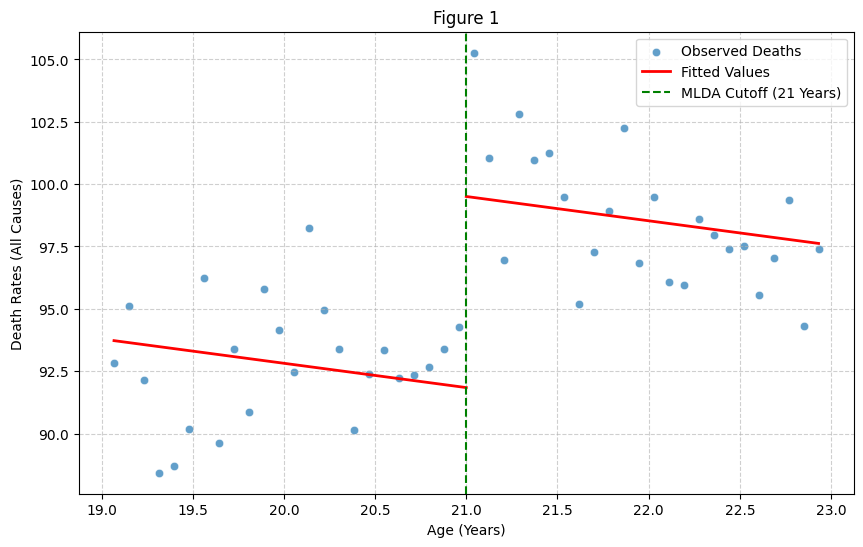

In [ ]:
formula = "all ~ over21 + agecell"
# Fit the OLS model
model = smf.ols(formula=formula, data=df1)
results = model.fit()

# Get the fitted values from the regression
df1['predicted_all1'] = results.predict(df1)

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='agecell', y='all', data=df1, label='Observed Deaths', alpha=0.7)

# Plot the fitted regression line
# Sort the DataFrame by 'agecell' to ensure the line is drawn correctly
df_sorted = df1.sort_values(by='agecell')
# below 21
sns.lineplot(
    x='agecell',
    y='predicted_all1',
    data=df_sorted[df_sorted['agecell'] < 21],
    color='red',
    linewidth=2,
    label='Linear Fitted Values'
)

# above 21
sns.lineplot(
    x='agecell',
    y='predicted_all1',
    data=df_sorted[df_sorted['agecell'] >= 21],
    color='red',
    linewidth=2,
)
# Add a vertical line at the MLDA cutoff (agecell = 21)
plt.axvline(x=21, color='green', linestyle='--', label='MLDA Cutoff (21 Years)')

plt.title('Figure 1')
plt.xlabel('Age (Years)')
plt.ylabel('Death Rates (All Causes)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

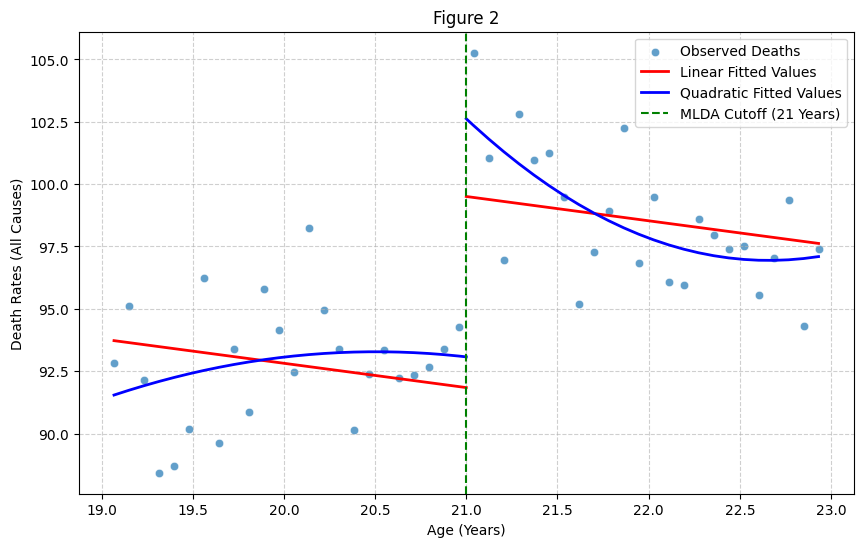

In [ ]:
# Question 2
#quadratic/interacted model
formula2 = "all ~ over21 + age_c + age_c_sq + over21_age_c + over21_age_c_sq"

# Fit the quadratic OLS model
model2 = smf.ols(formula=formula2, data=df1)
results2 = model2.fit()

# Get the fitted values from the regression
df1['predicted_all2'] = results2.predict(df1)

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='agecell', y='all', data=df1, label='Observed Deaths', alpha=0.7)

# Plot the fitted regression line
# Sort the DataFrame by agecell to ensure the line is drawn correctly
df_sorted = df1.sort_values(by='agecell')

#linear again:
# below 21
sns.lineplot(
    x='agecell',
    y='predicted_all1',
    data=df_sorted[df_sorted['agecell'] < 21],
    color='red',
    linewidth=2,
    label='Linear Fitted Values'
)

# above 21
sns.lineplot(
    x='agecell',
    y='predicted_all1',
    data=df_sorted[df_sorted['agecell'] >= 21],
    color='red',
    linewidth=2,
)

#plot quadratic/interacted line:
#below 21
sns.lineplot(
    x='agecell',
    y='predicted_all2',
    data=df_sorted[df_sorted['agecell'] < 21],
    color='blue',
    linewidth=2,
    label='Quadratic Fitted Values'
)

# above 21
sns.lineplot(
    x='agecell',
    y='predicted_all2',
    data=df_sorted[df_sorted['agecell'] >= 21],
    color='blue',
    linewidth=2,
)

# Add a vertical line at the MLDA cutoff (agecell = 21)
plt.axvline(x=21, color='green', linestyle='--', label='MLDA Cutoff (21 Years)')

plt.title('Figure 2')
plt.xlabel('Age (Years)')
plt.ylabel('Death Rates (All Causes)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

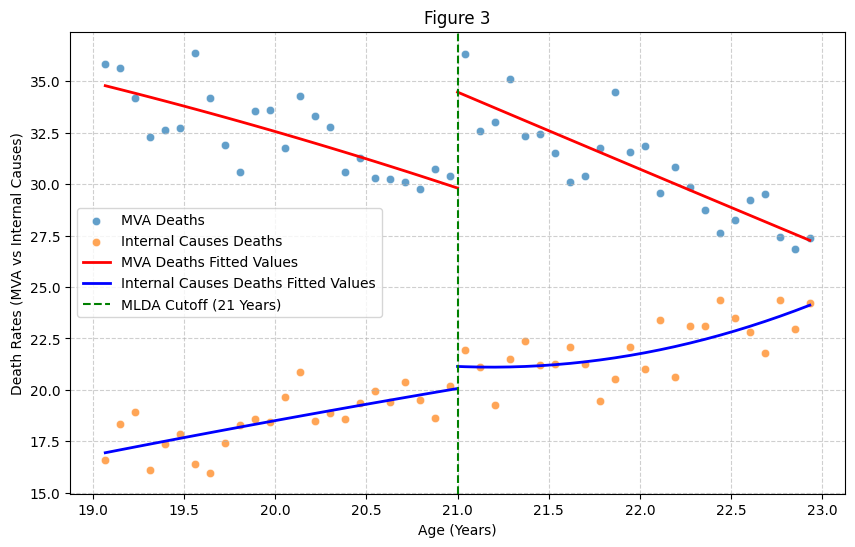

In [ ]:
# Question 2

formula3 = "mva ~ over21 + agecell + agecell_sq + over21_age + over21_age_sq"
formula4 = "internal ~ over21 + agecell + agecell_sq + over21_age + over21_age_sq"

# Fit the new OLS model
#mva:
model3 = smf.ols(formula=formula3, data=df1)
results3 = model3.fit()
#internal:
model4 = smf.ols(formula=formula4, data=df1)
results4 = model4.fit()


# Get the fitted values from the regression
#mva:
df1['predicted_all3'] = results3.predict(df1)
#internal:
df1['predicted_all4'] = results4.predict(df1)

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='agecell', y='mva', data=df1, label='MVA Deaths', alpha=0.7)
sns.scatterplot(x='agecell', y='internal', data=df1, label='Internal Causes Deaths', alpha=0.7)

# Plot the fitted regression line
# Sort the DataFrame by 'agecell' to ensure the line is drawn correctly
df_sorted = df1.sort_values(by='agecell')
# below 21
sns.lineplot(
    x='agecell',
    y='predicted_all3',
    data=df_sorted[df_sorted['agecell'] < 21],
    color='red',
    linewidth=2,
    label='MVA Deaths Fitted Values'
)

# above 21
sns.lineplot(
    x='agecell',
    y='predicted_all3',
    data=df_sorted[df_sorted['agecell'] >= 21],
    color='red',
    linewidth=2,
)
#below 21
sns.lineplot(
    x='agecell',
    y='predicted_all4',
    data=df_sorted[df_sorted['agecell'] < 21],
    color='blue',
    linewidth=2,
    label='Internal Causes Deaths Fitted Values'
)

# above 21
sns.lineplot(
    x='agecell',
    y='predicted_all4',
    data=df_sorted[df_sorted['agecell'] >= 21],
    color='blue',
    linewidth=2,
)

# Add a vertical line at the MLDA cutoff (agecell = 21)
plt.axvline(x=21, color='green', linestyle='--', label='MLDA Cutoff (21 Years)')

plt.title('Figure 3')
plt.xlabel('Age (Years)')
plt.ylabel('Death Rates (MVA vs Internal Causes)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
# Question 4: Regression table

# Outcomes in the same order
outcomes = [
    ("all", "All deaths"),
    ("mva", "Motor vehicle accidents"),
    ("suicide", "Suicide"),
    ("homicide", "Homicide"),
    ("externalother", "Other external causes"),
    ("internal", "All internal causes"),
    ("alcohol", "Alcohol-related disease")
]

# Sample Restrictions
df_19_22 = df1[(df1["agecell"] >= 19) & (df1["agecell"] < 23)].copy()
df_20_21 = df1[(df1["agecell"] >= 20) & (df1["agecell"] < 22)].copy()

# Regression helper
def run_rd(data, yvar, quadratic=False):
    if quadratic:
        formula = f"{yvar} ~ over21 + age_c + age_c_sq + over21_age_c + over21_age_c_sq"
    else:
        formula = f"{yvar} ~ over21 + agecell"

    model = smf.ols(formula=formula, data=data)

    # robust SE
    results = model.fit(cov_type="HC1")

    coef = results.params["over21"]
    se = results.bse["over21"]
    n = int(results.nobs)
    return coef, se, n, results

# Store results
table_rows = []

for var, label in outcomes:
    # Column 1: Ages 19-22, linear
    c1, se1, n1, r1 = run_rd(df_19_22, var, quadratic=False)

    # Column 2: Ages 19-22, quadratic + interactions
    c2, se2, n2, r2 = run_rd(df_19_22, var, quadratic=True)

    # Column 3: Ages 20-21, linear
    c3, se3, n3, r3 = run_rd(df_20_21, var, quadratic=False)

    # Column 4: Ages 20-21, quadratic + interactions
    c4, se4, n4, r4 = run_rd(df_20_21, var, quadratic=True)

    table_rows.append([
        label,
        f"{c1:.3f}",
        f"{c2:.3f}",
        f"{c3:.3f}",
        f"{c4:.3f}",
    ])
    table_rows.append([
        "",
        f"({se1:.3f})",
        f"({se2:.3f})",
        f"({se3:.3f})",
        f"({se4:.3f})",
    ])

# Add control rows
table_rows.append([
    "Controls",
    "age",
    "age, age$^2$, interactions with over-21",
    "age",
    "age, age$^2$, interactions with over-21"
])

table_rows.append([
    "Sample size",
    str(n1),
    str(n2),
    str(n3),
    str(n4)
])

table_df = pd.DataFrame(
    table_rows,
    columns=["Dependent variable", "(1)", "(2)", "(3)", "(4)"]
)

In [ ]:
table_df

,Dependent variable,(1),(2),(3),(4)
0,All deaths,7.663,9.548,9.753,9.611
1,,(1.514),(1.830),(2.064),(2.291)
2,Motor vehicle accidents,4.534,4.663,4.759,5.892
3,,(0.717),(1.093),(1.082),(1.329)
4,Suicide,1.794,1.814,1.724,1.297
5,,(0.496),(0.782),(0.733),(1.140)
6,Homicide,0.104,0.200,0.164,-0.453
7,,(0.450),(0.502),(0.589),(0.927)
8,Other external causes,0.441,1.178,0.831,1.346
9,,(0.292),(0.348),(0.368),(0.425)


In [ ]:
#To make the latex for the table
latex_lines = []

latex_lines.append(r"\begin{table}[htbp]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Sharp RD estimates of MLDA effects on mortality}")
latex_lines.append(r"\label{tab:mlda}")
latex_lines.append(r"\begin{tabular}{lcccc}")
latex_lines.append(r"\toprule")

latex_lines.append(r" & \multicolumn{2}{c}{Ages 19--22} & \multicolumn{2}{c}{Ages 20--21} \\")
latex_lines.append(r"\cmidrule(lr){2-3} \cmidrule(lr){4-5}")
latex_lines.append(r"Dependent variable & (1) & (2) & (3) & (4) \\")
latex_lines.append(r"\midrule")

for _, row in table_df.iterrows():
    dep = row["Dependent variable"]
    c1 = row["(1)"]
    c2 = row["(2)"]
    c3 = row["(3)"]
    c4 = row["(4)"]

    latex_lines.append(f"{dep} & {c1} & {c2} & {c3} & {c4} \\\\")

latex_lines.append(r"\midrule")
latex_lines.append(r"\multicolumn{5}{l}{\footnotesize Notes: Entries are coefficients on the over-21 dummy.} \\")
latex_lines.append(r"\multicolumn{5}{l}{\footnotesize Standard errors (HC1) are in parentheses.} \\")
latex_lines.append(r"\multicolumn{5}{l}{\footnotesize Columns (1) and (3) include linear age controls.} \\")
latex_lines.append(r"\multicolumn{5}{l}{\footnotesize Columns (2) and (4) additionally include quadratic age controls and interactions.} \\")
latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"\end{table}")

latex_table = "\n".join(latex_lines)

print(latex_table)

\begin{table}[htbp]
\centering
\caption{Regression discontinuity estimates of MLDA effects on mortality}
\label{tab:mlda}
\begin{tabular}{lcccc}
\toprule
 & \multicolumn{2}{c}{Ages 19--22} & \multicolumn{2}{c}{Ages 20--21} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5}
Dependent variable & (1) & (2) & (3) & (4) \\
\midrule
All deaths & 7.663 & 9.548 & 9.753 & 9.611 \\
 & (1.514) & (1.830) & (2.064) & (2.291) \\
Motor vehicle accidents & 4.534 & 4.663 & 4.759 & 5.892 \\
 & (0.717) & (1.093) & (1.082) & (1.329) \\
Suicide & 1.794 & 1.814 & 1.724 & 1.297 \\
 & (0.496) & (0.782) & (0.733) & (1.140) \\
Homicide & 0.104 & 0.200 & 0.164 & -0.453 \\
 & (0.450) & (0.502) & (0.589) & (0.927) \\
Other external causes & 0.441 & 1.178 & 0.831 & 1.346 \\
 & (0.292) & (0.348) & (0.368) & (0.425) \\
All internal causes & 0.392 & 1.073 & 1.692 & 1.249 \\
 & (0.543) & (0.802) & (0.745) & (1.012) \\
Alcohol-related disease & 0.442 & 0.799 & 0.740 & 1.028 \\
 & (0.206) & (0.324) & (0.333) & (0.413) \\
Controls 